# DiffWave × DODa — Prétraitement

Pipeline :
1. Chargement DODa (HuggingFace)
2. Mapping index → locuteur/genre (doc DODa)
3. Filtrage voix masculines (M1, M2, M3)
4. EDA
5. Prétraitement : mono → resample → peak norm → Mel → log
6. Sauvegarde `.wav` + `.npy`
7. Split train / val / test

## 0. Installation

In [1]:
!pip install -q datasets soundfile librosa torchaudio matplotlib pandas tqdm scikit-learn huggingface_hub

In [2]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## 1. Imports

In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
import torch
import torchaudio.transforms as T
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from pathlib import Path

import torch, torchaudio
print(f"PyTorch {torch.__version__} — torchaudio {torchaudio.__version__} — librosa {librosa.__version__}")

PyTorch 2.10.0+cpu — torchaudio 2.10.0+cpu — librosa 0.11.0


## 2. Configuration (hyperparamètres DiffWave BASE — Kong et al. 2021, article section 5.1)

In [4]:
# Audio
SAMPLE_RATE = 22050   # fréquence cible DiffWave
RAW_SR      = 16000   # fréquence native DODa

# Mel
N_FFT      = 1024
HOP_LENGTH = 256
WIN_LENGTH = 1024
N_MELS     = 80
F_MIN      = 0.0
F_MAX      = 8000.0
POWER      = 1.0      # amplitude spectrogramme
LOG_OFFSET = 1e-5     # évite log(0)
CLIP_VAL   = -11.5    # plancher silence

# Sorties
OUT_DIR = Path("data_preprocessed")
WAV_DIR = OUT_DIR / "wavs"
MEL_DIR = OUT_DIR / "mels"
WAV_DIR.mkdir(parents=True, exist_ok=True)
MEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"SR cible : {SAMPLE_RATE} Hz | N_FFT={N_FFT} | HOP={HOP_LENGTH} | N_MELS={N_MELS}")

SR cible : 22050 Hz | N_FFT=1024 | HOP=256 | N_MELS=80


## 3. Chargement du dataset

In [5]:
dataset = load_dataset("atlasia/DODa-audio-dataset", split="train")
print(f"DODa chargé : {len(dataset)} exemples | colonnes : {dataset.column_names}")

Using the latest cached version of the dataset since atlasia/DODa-audio-dataset couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /root/.cache/huggingface/datasets/atlasia___do_da-audio-dataset/default/0.0.0/588aec51a3f007fa23082766ce801c483b5cc0bb (last modified on Mon May  4 20:11:15 2026).


DODa chargé : 12743 exemples | colonnes : ['audio', 'darija_Latn', 'darija_Arab_new', 'english', 'darija_Arab_old']


## 4. Mapping index → locuteur / genre
DODa n'expose pas de colonne `speaker_id`. Le mapping est reconstruit depuis la documentation officielle (BIDRY et al., 2025).

In [6]:
SPEAKER_RANGES = [
    (0,     999,   "F1", "female"),
    (1000,  1999,  "M3", "male"),
    (2000,  2730,  "F2", "female"),
    (2731,  2800,  "M1", "male"),
    (2801,  2999,  "M2", "male"),
    (3000,  3999,  "M2", "male"),
    (4000,  4999,  "M1", "male"),
    (5000,  5999,  "F3", "female"),
    (6000,  6999,  "M1", "male"),
    (7000,  7999,  "F4", "female"),
    (8000,  8999,  "F1", "female"),
    (9000,  9999,  "M2", "male"),
    (10000, 10999, "M1", "male"),
    (11000, 11999, "M1", "male"),
    (12000, 12350, "M2", "male"),
    (12351, 12742, "M1", "male"),
]

def get_speaker_info(idx):
    for start, end, speaker, gender in SPEAKER_RANGES:
        if start <= idx <= end:
            return speaker, gender
    return "unknown", "unknown"

# Vérification
for i in [0, 1000, 2731, 4000, 9000, 12742]:
    spk, gen = get_speaker_info(i)
    print(f"  idx {i:>6} → {spk} ({gen})")

  idx      0 → F1 (female)
  idx   1000 → M3 (male)
  idx   2731 → M1 (male)
  idx   4000 → M1 (male)
  idx   9000 → M2 (male)
  idx  12742 → M1 (male)


## 5. Filtrage — voix masculines uniquement

In [7]:
male_indices = [i for i in range(len(dataset)) if get_speaker_info(i)[1] == "male"]
dataset_male = dataset.select(male_indices)

print(f"Total DODa : {len(dataset)}")
print(f"Voix masculines : {len(male_indices)} (M1, M2, M3)")
print(f"Voix féminines : {len(dataset) - len(male_indices)} (exclues)")

Total DODa : 12743
Voix masculines : 8012 (M1, M2, M3)
Voix féminines : 4731 (exclues)


## 6. EDA

In [8]:
def build_metadata(dataset_filtered, global_indices):
    """Construit un dataframe de métadonnées pour les exemples filtrés."""
    records = []
    for local_i, global_i in enumerate(tqdm(global_indices, desc="EDA")):
        audio = dataset_filtered[local_i]["audio"]
        sr = audio["sampling_rate"]
        duration = len(audio["array"]) / sr
        spk, _ = get_speaker_info(global_i)
        records.append({
            "id" : f"{global_i:05d}",
            "global_idx" : global_i,
            "speaker" : spk,
            "duration_s" : round(duration, 3),
            "text_latin" : dataset_filtered[local_i].get("darija_Latn", ""),
        })
    return pd.DataFrame(records)

df_eda = build_metadata(dataset_male, male_indices)

print(f"Durée totale : {df_eda['duration_s'].sum() / 3600:.2f} h")
print(df_eda.groupby("speaker")["duration_s"].agg(["count", "sum", "mean"]).round(2))

EDA:   0%|          | 0/8012 [00:00<?, ?it/s]

Durée totale : 6.26 h
         count       sum  mean
speaker                       
M1        4462  12076.09  2.71
M2        2550   7670.40  3.01
M3        1000   2787.85  2.79


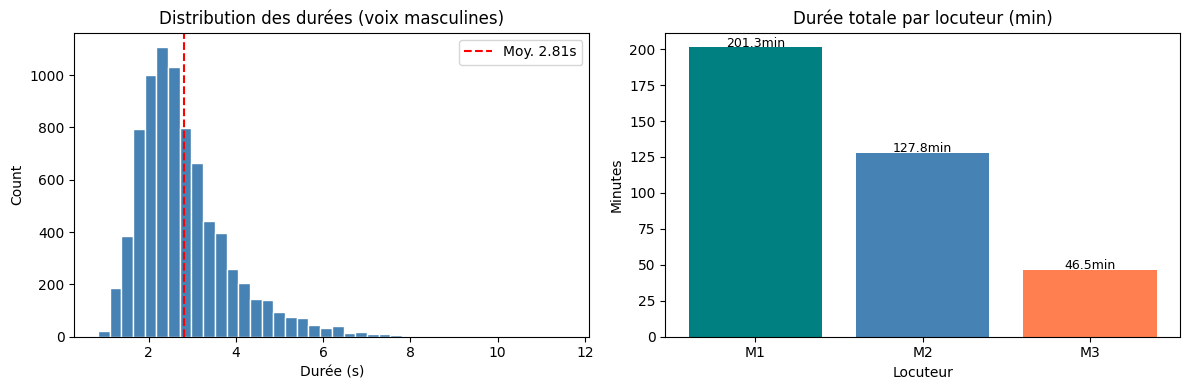

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution des durées
axes[0].hist(df_eda["duration_s"], bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(df_eda["duration_s"].mean(), color="red", linestyle="--",
                label=f"Moy. {df_eda['duration_s'].mean():.2f}s")
axes[0].set_title("Distribution des durées (voix masculines)")
axes[0].set_xlabel("Durée (s)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Durée par locuteur
spk_dur = df_eda.groupby("speaker")["duration_s"].sum() / 60
axes[1].bar(spk_dur.index, spk_dur.values, color=["teal", "steelblue", "coral"])
axes[1].set_title("Durée totale par locuteur (min)")
axes[1].set_xlabel("Locuteur")
axes[1].set_ylabel("Minutes")
for i, (spk, val) in enumerate(spk_dur.items()):
    axes[1].text(i, val + 0.5, f"{val:.1f}min", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "eda_male.png", dpi=150)
plt.show()

ID : 01000
Locuteur : M3
Transcription : wach khssna ndowwro?
SR natif : 16000 Hz | Durée : 2.54s


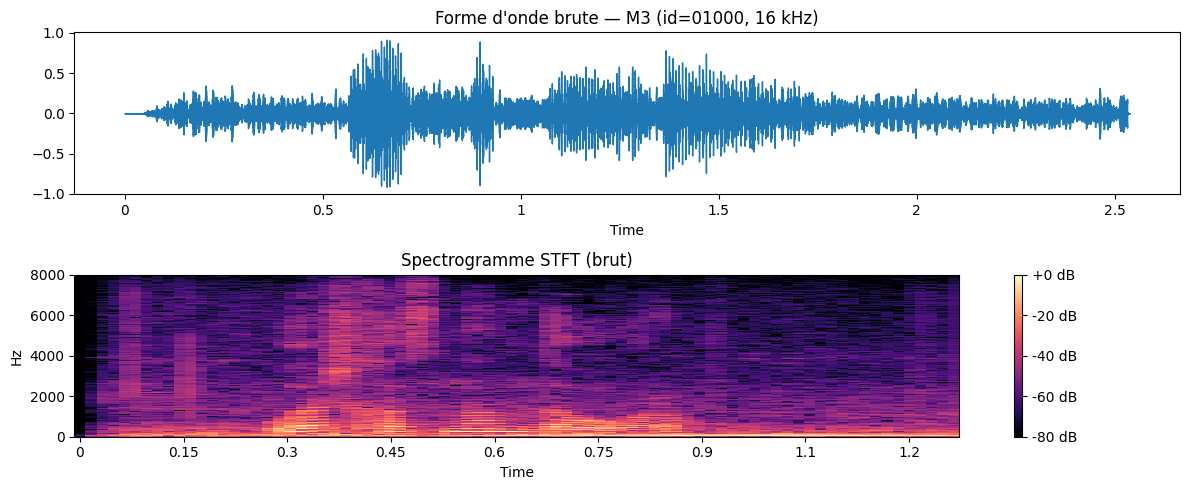

In [10]:
# Inspection d'un exemple brut (1er exemple masculin)
import IPython.display as ipd

sample = dataset_male[0]
wav_raw = np.array(sample["audio"]["array"], dtype=np.float32)
sr_raw = sample["audio"]["sampling_rate"]
spk, _ = get_speaker_info(male_indices[0])

print(f"ID : {male_indices[0]:05d}")
print(f"Locuteur : {spk}")
print(f"Transcription : {sample.get('darija_Latn', '')}")
print(f"SR natif : {sr_raw} Hz | Durée : {len(wav_raw)/sr_raw:.2f}s")

fig, axes = plt.subplots(2, 1, figsize=(12, 5))
librosa.display.waveshow(wav_raw, sr=sr_raw, ax=axes[0])
axes[0].set_title(f"Forme d'onde brute — {spk} (id={male_indices[0]:05d}, 16 kHz)")
D = librosa.amplitude_to_db(np.abs(librosa.stft(wav_raw)), ref=np.max)
librosa.display.specshow(D, sr=sr_raw, hop_length=HOP_LENGTH,
                         x_axis="time", y_axis="hz", ax=axes[1])
axes[1].set_title("Spectrogramme STFT (brut)")
plt.colorbar(axes[1].collections[0], ax=axes[1], format="%+2.0f dB")
plt.tight_layout()
plt.show()
ipd.display(ipd.Audio(wav_raw, rate=sr_raw))

## 7. Pipeline de prétraitement

In [11]:
mel_transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    win_length=WIN_LENGTH,
    n_mels=N_MELS,
    f_min=F_MIN,
    f_max=F_MAX,
    power=POWER,
)

def preprocess_audio(audio_dict):
    """
    Entrée : dict HuggingFace {"array": np.ndarray, "sampling_rate": int}
    Sortie : (wav: Tensor[1,T], mel: Tensor[80,F])

    Étapes :
      1. Mono
      2. Rééchantillonnage → 22 050 Hz
      3. Normalisation peak
      4. Mel-spectrogramme (80 bandes, config DiffWave)
      5. Log-compression
    """
    wav = torch.tensor(audio_dict["array"], dtype=torch.float32)
    src_sr = audio_dict["sampling_rate"]

    # 1. Mono
    if wav.dim() == 1:
        wav = wav.unsqueeze(0)
    elif wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)

    # 2. Rééchantillonnage
    if src_sr != SAMPLE_RATE:
        wav = T.Resample(orig_freq=src_sr, new_freq=SAMPLE_RATE)(wav)

    # 3. Normalisation peak
    peak = wav.abs().max()
    if peak > 0:
        wav = wav / peak * 0.95

    # 4. Mel-spectrogramme
    mel = mel_transform(wav).squeeze(0)   # [80, F]

    # 5. Log-compression
    mel = torch.log(mel.clamp(min=LOG_OFFSET)).clamp(min=CLIP_VAL)

    return wav, mel

# Test rapide
wav_t, mel_t = preprocess_audio(dataset_male[0]["audio"])
print(f"wav : {wav_t.shape} | mel : {mel_t.shape} | mel range : [{mel_t.min():.2f}, {mel_t.max():.2f}]")

wav : torch.Size([1, 55979]) | mel : torch.Size([80, 219]) | mel range : [-11.50, 4.63]


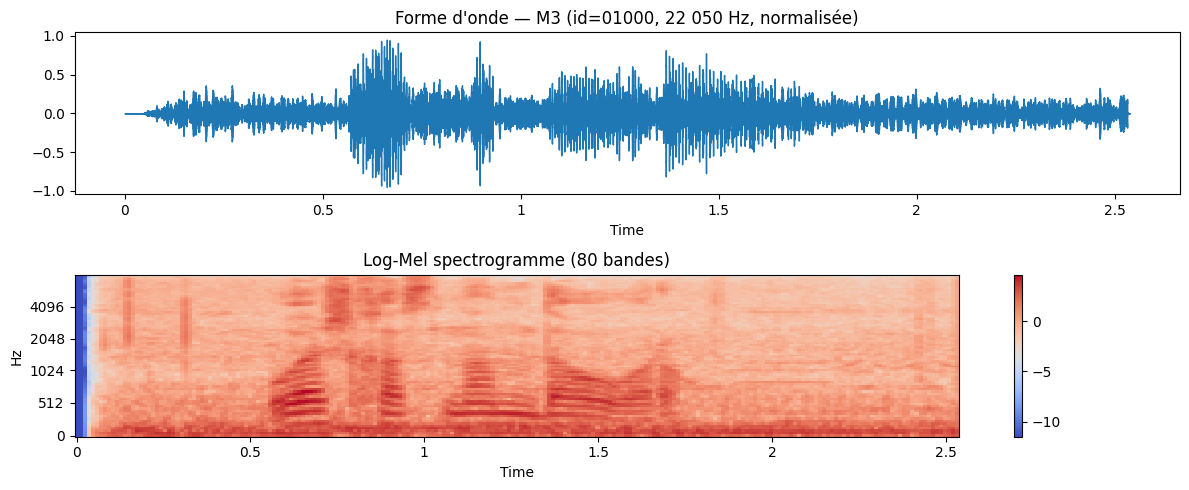

In [12]:
# Visualisation après prétraitement
fig, axes = plt.subplots(2, 1, figsize=(12, 5))
librosa.display.waveshow(wav_t.squeeze().numpy(), sr=SAMPLE_RATE, ax=axes[0])
axes[0].set_title(f"Forme d'onde — {spk} (id={male_indices[0]:05d}, 22 050 Hz, normalisée)")
librosa.display.specshow(mel_t.numpy(), sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                         x_axis="time", y_axis="mel", fmax=F_MAX, ax=axes[1])
axes[1].set_title("Log-Mel spectrogramme (80 bandes)")
plt.colorbar(axes[1].collections[0], ax=axes[1])
plt.tight_layout()
plt.show()

## 8. Traitement du corpus masculin complet

In [13]:
def process_corpus(dataset_filtered, global_indices):
    """Applique le pipeline sur tout le corpus et sauvegarde les fichiers."""
    manifest = []

    for local_i, global_i in enumerate(tqdm(global_indices, desc="Preprocessing")):
        item = dataset_filtered[local_i]
        spk, _ = get_speaker_info(global_i)
        uid = f"{global_i:05d}"

        wav_t, mel_t = preprocess_audio(item["audio"])

        wav_path = WAV_DIR / f"{uid}.wav"
        mel_path = MEL_DIR / f"{uid}.npy"

        sf.write(wav_path, wav_t.squeeze().numpy(), SAMPLE_RATE, subtype="PCM_16")
        np.save(mel_path, mel_t.numpy().astype(np.float32))

        manifest.append({
            "id" : uid,
            "speaker" : spk,
            "text_latin" : item.get("darija_Latn", ""),
            "wav_path" : str(wav_path),
            "mel_path" : str(mel_path),
            "duration_s" : round(wav_t.shape[-1] / SAMPLE_RATE, 3),
            "mel_frames" : mel_t.shape[-1],
        })

    return pd.DataFrame(manifest)

df_manifest = process_corpus(dataset_male, male_indices)
print(f"\nExemples traités : {len(df_manifest)}")
print(f"Durée totale : {df_manifest['duration_s'].sum() / 3600:.2f} h")

Preprocessing:   0%|          | 0/8012 [00:00<?, ?it/s]


Exemples traités : 8012
Durée totale : 6.26 h


## 9. Split train / val / test

In [14]:
def split_dataset(df, test_size=0.10, val_size=0.10, seed=42):
    """Split stratifié par locuteur : 80/10/10."""
    train_val, test_df = train_test_split(
        df, test_size=test_size, random_state=seed, stratify=df["speaker"]
    )
    train_df, val_df = train_test_split(
        train_val, test_size=val_size, random_state=seed, stratify=train_val["speaker"]
    )
    return train_df, val_df, test_df

train_df, val_df, test_df = split_dataset(df_manifest)

print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")
print("\nRépartition locuteurs :")
for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f" {name} : {dict(split['speaker'].value_counts())}")

train_df.to_csv(OUT_DIR / "train.csv", index=False)
val_df.to_csv(OUT_DIR / "val.csv", index=False)
test_df.to_csv(OUT_DIR / "test.csv", index=False)
print("\nCSV sauvegardés.")

Train : 6489 | Val : 721 | Test : 802

Répartition locuteurs :
 train : {'M1': np.int64(3613), 'M2': np.int64(2066), 'M3': np.int64(810)}
 val : {'M1': np.int64(402), 'M2': np.int64(229), 'M3': np.int64(90)}
 test : {'M1': np.int64(447), 'M2': np.int64(255), 'M3': np.int64(100)}

CSV sauvegardés.


## 10. Vérification visuelle finale

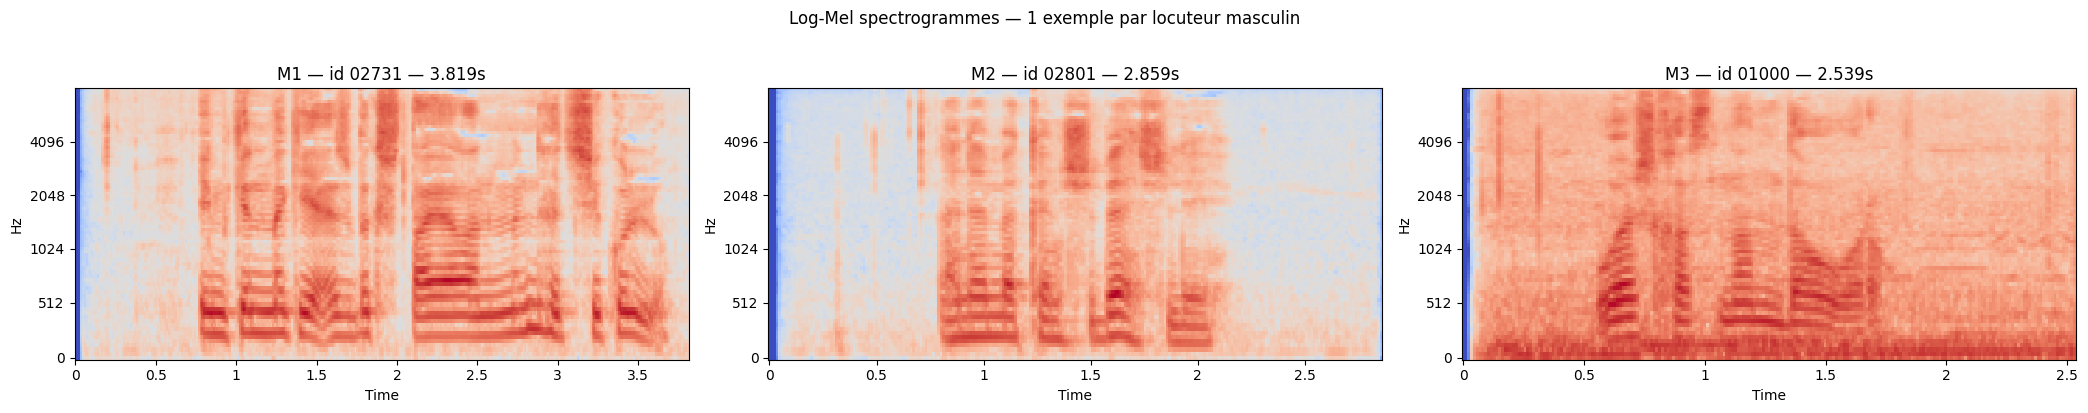

In [15]:
# 1 exemple par locuteur
samples = df_manifest.groupby("speaker").first().reset_index()
fig, axes = plt.subplots(1, len(samples), figsize=(7 * len(samples), 4))

for ax, (_, row) in zip(axes, samples.iterrows()):
    mel = np.load(row["mel_path"])
    librosa.display.specshow(
        mel, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
        x_axis="time", y_axis="mel", fmax=F_MAX, ax=ax
    )
    ax.set_title(f"{row['speaker']} - id {row['id']} - {row['duration_s']}s")

plt.suptitle("Log-Mel spectrogrammes - 1 exemple par locuteur masculin", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "sample_mels_per_speaker.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Résumé

In [16]:
summary = {
    "dataset": "atlasia/DODa-audio-dataset",
    "filtre" : "voix masculines (M1, M2, M3)",
    "exemples_traites" : len(df_manifest),
    "duree_totale_h" : round(df_manifest["duration_s"].sum() / 3600, 3),
    "locuteurs" : sorted(df_manifest["speaker"].unique().tolist()),
    "sample_rate" : SAMPLE_RATE,
    "n_mels" : N_MELS,
    "n_fft" : N_FFT,
    "hop_length" : HOP_LENGTH,
    "splits" : {"train": len(train_df), "val": len(val_df), "test": len(test_df)},
}

with open(OUT_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("-" * 10)
print("RÉSUMÉ PRÉTRAITEMENT")
print("-" * 10)
for k, v in summary.items():
    print(f"  {k:<24} : {v}")
print("-" * 10)
print(f"\nFichiers dans : {OUT_DIR.resolve()}")
print("Prochaine étape : entraînement DiffWave avec train.csv")

----------
RÉSUMÉ PRÉTRAITEMENT
----------
  dataset                  : atlasia/DODa-audio-dataset
  filtre                   : voix masculines (M1, M2, M3)
  exemples_traites         : 8012
  duree_totale_h           : 6.26
  locuteurs                : ['M1', 'M2', 'M3']
  sample_rate              : 22050
  n_mels                   : 80
  n_fft                    : 1024
  hop_length               : 256
  splits                   : {'train': 6489, 'val': 721, 'test': 802}
----------

Fichiers dans : /content/data_preprocessed
Prochaine étape : entraînement DiffWave avec train.csv
